# <a id='toc1_'></a>[Imports](#toc0_)

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import lightgbm as lgb
from lightgbm import LGBMClassifier
import xgboost as xgb
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    f1_score,
    fbeta_score,
    precision_score,
    recall_score,
    confusion_matrix,
    make_scorer,
)
from sklearn.model_selection import KFold, StratifiedKFold, train_test_split
from sklearn.utils.class_weight import compute_sample_weight
import mlflow
from mlflow import MlflowClient
import optuna
import plotly.graph_objects as go
import tempfile, os

optuna.logging.set_verbosity(optuna.logging.WARNING)

# <a id='toc2_'></a>[Chargement des données](#toc0_)

## <a id='toc2_1_'></a>[Lecture des fichiers CSV](#toc0_)

In [4]:
df_full = pd.read_csv("df.csv")
df_red = pd.read_csv("df_red.csv")

## <a id='toc2_2_'></a>[Sélection du dataset](#toc0_)

In [5]:
use_reduced = False  # flip to False for full run
df = df_red.copy() if use_reduced else df_full.copy()

## <a id='toc2_3_'></a>[Aperçu](#toc0_)

In [5]:
df

,SK_ID_CURR,TARGET,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,...,CC_SK_DPD_DEF_VAR,CC_NAME_CONTRACT_STATUS_Active_MEAN,CC_NAME_CONTRACT_STATUS_Approved_MEAN,CC_NAME_CONTRACT_STATUS_Completed_MEAN,CC_NAME_CONTRACT_STATUS_Demand_MEAN,CC_NAME_CONTRACT_STATUS_Refused_MEAN,CC_NAME_CONTRACT_STATUS_Sent proposal_MEAN,CC_NAME_CONTRACT_STATUS_Signed_MEAN,CC_NAME_CONTRACT_STATUS_nan_MEAN,CC_COUNT
0,100002,1,0,0,0,0,202500.0,406597.5,24700.5,351000.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,100003,0,1,0,1,0,270000.0,1293502.5,35698.5,1129500.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,100004,0,0,1,0,0,67500.0,135000.0,6750.0,135000.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,100006,0,1,0,0,0,135000.0,312682.5,29686.5,297000.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.0
4,100007,0,0,0,0,0,121500.0,513000.0,21865.5,513000.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
307506,456251,0,0,0,1,0,157500.0,254700.0,27558.0,225000.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
307507,456252,0,1,0,0,0,72000.0,269550.0,12001.5,225000.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
307508,456253,0,1,0,0,0,153000.0,677664.0,29979.0,585000.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
307509,456254,1,1,0,0,0,171000.0,370107.0,20205.0,319500.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# <a id='toc3_'></a>[Utilitaires](#toc0_)

## <a id='toc3_1_'></a>[Fonctions de logging MLflow](#toc0_)

In [6]:
log_model_fn = {
    LGBMClassifier: mlflow.lightgbm.log_model,
}

## <a id='toc3_2_'></a>[Gestion des runs](#toc0_)

In [6]:
def delete_run_if_exists(experiment_name, run_name):
    client = MlflowClient()
    exp = client.get_experiment_by_name(experiment_name)
    if exp is None:
        return
    runs = client.search_runs(
        experiment_ids=[exp.experiment_id],
        filter_string=f"tags.mlflow.runName = '{run_name}'",
    )
    for run in runs:
        client.delete_run(run.info.run_id)

## <a id='toc3_3_'></a>[Pipeline sklearn](#toc0_)

In [7]:
def cost_score(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return 10 * fn + fp  # positif = à minimiser


scorer = make_scorer(cost_score, greater_is_better=False)

In [8]:
def find_best_threshold(y_true, y_proba, n_steps=100):
    """Retourne le seuil qui minimise le coût métier (10*FN + FP)."""
    thresholds = np.linspace(0.01, 0.99, n_steps)
    costs = [cost_score(y_true, (y_proba >= t).astype(int)) for t in thresholds]
    best_idx = np.argmin(costs)
    return thresholds[best_idx]

# <a id='toc4_'></a>[Préparation des données](#toc0_)

## <a id='toc4_1_'></a>[Features & target](#toc0_)

In [9]:
X = df.drop(columns=["TARGET", "SK_ID_CURR"])
y = df["TARGET"]


# Fix noms de colonnes pour LightGBM
import re

X.columns = [re.sub(r"[^A-Za-z0-9_]+", "_", col) for col in X.columns]

# on enleve les inf pour eviter de faire bugger certains modeles
X = X.replace([np.inf, -np.inf], np.nan)


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=78
)

## <a id='toc4_2_'></a>[Statistiques du split](#toc0_)

In [11]:
y_train.value_counts()

TARGET
0    226073
1     19932
Name: count, dtype: int64

In [12]:
y_test.value_counts()

TARGET
0    56609
1     4893
Name: count, dtype: int64

# <a id='toc5_'></a>[Configuration MLflow](#toc0_)

In [16]:
if mlflow.active_run():
    mlflow.end_run()

mlflow.set_tracking_uri("http://127.0.0.1:5000/")
EXPERIMENT_NAME = "OC_P6_optimisation"
mlflow.set_experiment(EXPERIMENT_NAME)

<Experiment: artifact_location='mlflow-artifacts:/3', creation_time=1774856089058, experiment_id='3', last_update_time=1774856089058, lifecycle_stage='active', name='OC_P6_optimisation', tags={}, workspace='default'>

# <a id='toc6_'></a>[Modélisation](#toc0_)

## <a id='toc6_1_'></a>[Fonction run_cv](#toc0_)

In [25]:
FBETA = 1.5


def run_cv(
    model,
    model_name,
    X,
    y,
    n_splits=5,
    tags=None,
    use_sample_weights=False,
    optimize_threshold=False,
):
    delete_run_if_exists(EXPERIMENT_NAME, model_name)
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    aucs, pr_aucs, recalls, precisions, f1s, fbetas, costs, thresholds = (
        [],
        [],
        [],
        [],
        [],
        [],
        [],
        [],
    )
    sw_key = "model__sample_weight" if isinstance(model, Pipeline) else "sample_weight"

    with mlflow.start_run(run_name=model_name, tags=tags or {}):
        mlflow.log_params({k: str(v) for k, v in model.get_params().items()})
        mlflow.log_param("model_name", model_name)
        mlflow.log_param("sample_weight", "balanced" if use_sample_weights else "none")
        mlflow.log_param("optimize_threshold", str(optimize_threshold))
        base = model.steps[-1][1] if isinstance(model, Pipeline) else model
        mlflow.set_tag("model_family", type(base).__name__)
        for fold, (tr, val) in enumerate(skf.split(X, y)):
            sw = (
                {sw_key: compute_sample_weight("balanced", y.iloc[tr])}
                if use_sample_weights
                else {}
            )
            model.fit(X.iloc[tr], y.iloc[tr], **sw)
            preds_proba = model.predict_proba(X.iloc[val])[:, 1]
            if optimize_threshold:
                thresh = find_best_threshold(y.iloc[val], preds_proba)
                thresholds.append(thresh)
            else:
                thresh = 0.5
            preds = (preds_proba >= thresh).astype(int)
            aucs.append(roc_auc_score(y.iloc[val], preds_proba))
            pr_aucs.append(average_precision_score(y.iloc[val], preds_proba))
            recalls.append(recall_score(y.iloc[val], preds, zero_division=0))
            precisions.append(precision_score(y.iloc[val], preds, zero_division=0))
            f1s.append(f1_score(y.iloc[val], preds, zero_division=0))
            fbetas.append(fbeta_score(y.iloc[val], preds, beta=FBETA, zero_division=0))
            costs.append(cost_score(y.iloc[val], preds))
        mlflow.log_metric("roc_auc_mean", round(float(np.mean(aucs)), 2))
        mlflow.log_metric("roc_auc_std", round(float(np.std(aucs)), 2))
        mlflow.log_metric("pr_auc_mean", round(float(np.mean(pr_aucs)), 2))
        mlflow.log_metric("pr_auc_std", round(float(np.std(pr_aucs)), 2))
        mlflow.log_metric("recall_mean", round(float(np.mean(recalls)), 2))
        mlflow.log_metric("recall_std", round(float(np.std(recalls)), 2))
        mlflow.log_metric("precision_mean", round(float(np.mean(precisions)), 2))
        mlflow.log_metric("precision_std", round(float(np.std(precisions)), 2))
        mlflow.log_metric("f1_mean", round(float(np.mean(f1s)), 2))
        mlflow.log_metric("f1_std", round(float(np.std(f1s)), 2))
        mlflow.log_metric("fbeta_mean", round(float(np.mean(fbetas)), 2))
        mlflow.log_metric("fbeta_std", round(float(np.std(fbetas)), 2))
        mlflow.log_metric("cost_mean", round(float(np.mean(costs)), 2))
        mlflow.log_metric("cost_std", round(float(np.std(costs)), 2))
        if optimize_threshold:
            mlflow.log_metric(
                "best_threshold_mean", round(float(np.mean(thresholds)), 2)
            )
            mlflow.log_metric("best_threshold_std", round(float(np.std(thresholds)), 2))

        sw = (
            {sw_key: compute_sample_weight("balanced", y)} if use_sample_weights else {}
        )
        model.fit(X, y, **sw)
        log_fn = log_model_fn.get(type(model), mlflow.sklearn.log_model)
        log_fn(model, name=model_name)

        thr_info = (
            f" | Threshold={np.mean(thresholds):.3f} ± {np.std(thresholds):.3f}"
            if optimize_threshold
            else ""
        )
        print(
            f"{model_name} | ROC-AUC={np.mean(aucs):.4f} | PR-AUC={np.mean(pr_aucs):.4f} | "
            f"Recall={np.mean(recalls):.4f} | Precision={np.mean(precisions):.4f} | "
            f"Fbeta(β={FBETA})={np.mean(fbetas):.4f} | Cost={np.mean(costs):.1f}{thr_info}"
        )

## <a id='toc6_2_'></a>[Entraînement initial](#toc0_)

In [15]:
# ini_tags = {"dataset": "reduced", "phase": "initial", "optimisation": "default"}

# run_cv(
#     LGBMClassifier(random_state=42, n_jobs=-1),
#     "lgbm_ini",
#     X_train,
#     y_train,
#     tags=ini_tags,
#     use_sample_weights=True,
#     optimize_threshold=True,
# )

In [ ]:
# ## Entrainement sur le full

# ini_tags = {"dataset": "full", "phase": "initial", "optimisation": "default" }

# run_cv(
#     LGBMClassifier(random_state=42, n_jobs=-1),
#     "lgbm_ini_full",
#     X_train,
#     y_train,
#     tags=ini_tags,
#     use_sample_weights=True,
#     optimize_threshold=True,
# )

2026/03/31 09:04:56 WARNING mlflow.lightgbm: Saving the models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/03/31 09:04:59 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


lgbm_ini_full | ROC-AUC=0.7825 | PR-AUC=0.2742 | Recall=0.6704 | Precision=0.1932 | Fbeta(β=1.5)=0.3801 | Cost=24355.8 | Threshold=0.511 ± 0.021
🏃 View run lgbm_ini_full at: http://127.0.0.1:5000/#/experiments/3/runs/875bb36e1cd945a1a597d2d52f963d41
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/3


# <a id='toc7_'></a>[Optimisation Optuna](#toc0_)

## <a id='toc7_1_'></a>[Fonction objective](#toc0_)

In [17]:
def objective(trial):
    params = {
        "num_leaves": trial.suggest_int("num_leaves", 20, 300),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "n_estimators": trial.suggest_int("n_estimators", 100, 1000),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 100),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
    }
    model = LGBMClassifier(**params, random_state=42, n_jobs=-1, verbose=-1)
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    costs = []
    for tr, val in skf.split(X_train, y_train):
        sw = compute_sample_weight("balanced", y_train.iloc[tr])
        model.fit(X_train.iloc[tr], y_train.iloc[tr], sample_weight=sw)
        preds_proba = model.predict_proba(X_train.iloc[val])[:, 1]
        thresh = find_best_threshold(y_train.iloc[val], preds_proba)
        preds = (preds_proba >= thresh).astype(int)
        costs.append(cost_score(y_train.iloc[val], preds))
    return np.mean(costs)

## <a id='toc7_2_'></a>[Lancement de la study](#toc0_)

In [18]:
N_TRIALS = 100  # flip à 100+ pour le full dataset
study = optuna.create_study(direction="minimize", study_name="lgbm_optuna")
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

  0%|          | 0/100 [00:00<?, ?it/s]

In [19]:
print(f"Meilleur coût : {study.best_value:.1f}")
print(f"Meilleurs params : {study.best_params}")

Meilleur coût : 23868.6
Meilleurs params : {'num_leaves': 264, 'learning_rate': 0.014287211983292707, 'n_estimators': 773, 'min_child_samples': 83, 'subsample': 0.8771054210270014, 'colsample_bytree': 0.801671563583984, 'reg_alpha': 6.930743941723339, 'reg_lambda': 0.4661687471215537}


## <a id='toc7_3_'></a>[Logging MLflow — meilleure trial](#toc0_)

In [20]:
best_model = LGBMClassifier(**study.best_params, random_state=42, n_jobs=-1)
run_cv(
    best_model,
    "lgbm_optuna_best_full",
    X_train,
    y_train,
    tags={"phase": "optuna", "dataset": "full"},
    use_sample_weights=True,
    optimize_threshold=True,
)

2026/03/31 06:47:18 WARNING mlflow.lightgbm: Saving the models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/03/31 06:47:22 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


lgbm_optuna_best_full | ROC-AUC=0.7883 | PR-AUC=0.2826 | Recall=0.6829 | Precision=0.1963 | Fbeta(β=1.5)=0.3862 | Cost=23868.6 | Threshold=0.333 ± 0.031
🏃 View run lgbm_optuna_best_full at: http://127.0.0.1:5000/#/experiments/3/runs/b298ae7fcceb49118aa342716d79bb95
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/3


## <a id='toc7_4_'></a>[Artefacts — courbe coût vs. seuil (OOF)](#toc0_)

In [21]:
skf_viz = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_proba = np.zeros(len(X_train))
for tr, val in skf_viz.split(X_train, y_train):
    m = LGBMClassifier(**study.best_params, random_state=42, n_jobs=-1, verbose=-1)
    sw = compute_sample_weight("balanced", y_train.iloc[tr])
    m.fit(X_train.iloc[tr], y_train.iloc[tr], sample_weight=sw)
    oof_proba[val] = m.predict_proba(X_train.iloc[val])[:, 1]

thresholds_range = np.linspace(0.01, 0.99, 200)
costs_range = [
    cost_score(y_train, (oof_proba >= t).astype(int)) for t in thresholds_range
]
best_thresh = thresholds_range[np.argmin(costs_range)]

fig_thresh = go.Figure()
fig_thresh.add_trace(
    go.Scatter(x=thresholds_range, y=costs_range, mode="lines", name="Coût")
)
fig_thresh.add_vline(
    x=best_thresh, line_dash="dash", annotation_text=f"Optimal: {best_thresh:.3f}"
)
fig_thresh.update_layout(
    title="Coût métier vs. seuil (OOF X_train)",
    xaxis_title="Seuil",
    yaxis_title="10*FN + FP",
)
fig_thresh.show()

## Artefacts — feature importances (top 10)

In [22]:
feat_imp = (
    pd.Series(best_model.feature_importances_, index=X_train.columns)
    .nlargest(10)
    .sort_values()
)

fig_imp = go.Figure(go.Bar(x=feat_imp.values, y=feat_imp.index, orientation="h"))
fig_imp.update_layout(
    title="Top 10 feature importances (LGBM)",
    xaxis_title="Importance",
    yaxis_title="Feature",
)
fig_imp.show()

## Évaluation sur X_test

In [23]:
preds_proba_test = best_model.predict_proba(X_test)[:, 1]
preds_test = (preds_proba_test >= best_thresh).astype(int)

test_metrics = {
    "test_roc_auc": round(float(roc_auc_score(y_test, preds_proba_test)), 2),
    "test_pr_auc": round(float(average_precision_score(y_test, preds_proba_test)), 2),
    "test_recall": round(float(recall_score(y_test, preds_test, zero_division=0)), 2),
    "test_precision": round(
        float(precision_score(y_test, preds_test, zero_division=0)), 2
    ),
    "test_f1": round(float(f1_score(y_test, preds_test, zero_division=0)), 2),
    "test_fbeta": round(
        float(fbeta_score(y_test, preds_test, beta=FBETA, zero_division=0)), 2
    ),
    "test_cost": round(float(cost_score(y_test, preds_test)), 2),
}

ORDER = ["roc_auc", "pr_auc", "recall", "precision", "cost", "f1", "fbeta"]
metrics_df = pd.DataFrame(
    [(k.replace("test_", ""), f"{v:.2f}") for k, v in test_metrics.items()],
    columns=["Métrique", "Valeur"],
)
metrics_df["Métrique"] = pd.Categorical(
    metrics_df["Métrique"], categories=ORDER, ordered=True
)
display(metrics_df.sort_values("Métrique").reset_index(drop=True))

# Confusion matrix
tn, fp, fn, tp = confusion_matrix(y_test, preds_test).ravel()
fig_cm = go.Figure(
    go.Heatmap(
        z=[[tn, fp], [fn, tp]],
        x=["Prédit 0", "Prédit 1"],
        y=["Réel 0", "Réel 1"],
        text=[[str(tn), str(fp)], [str(fn), str(tp)]],
        texttemplate="%{text}",
        colorscale="Blues",
    )
)
fig_cm.update_layout(title=f"Confusion matrix X_test (seuil={best_thresh:.3f})")
fig_cm.update_yaxes(autorange="reversed")
fig_cm.show()

,Métrique,Valeur
0,roc_auc,0.79
1,pr_auc,0.28
2,recall,0.71
3,precision,0.18
4,cost,29678.00
5,f1,0.29
6,fbeta,0.38


In [2]:
mlflow.set_tracking_uri("http://127.0.0.1:5000/")
best_model = mlflow.lightgbm.load_model("models:/lgbm_credit_scoring/2")

## Analyse SHAP

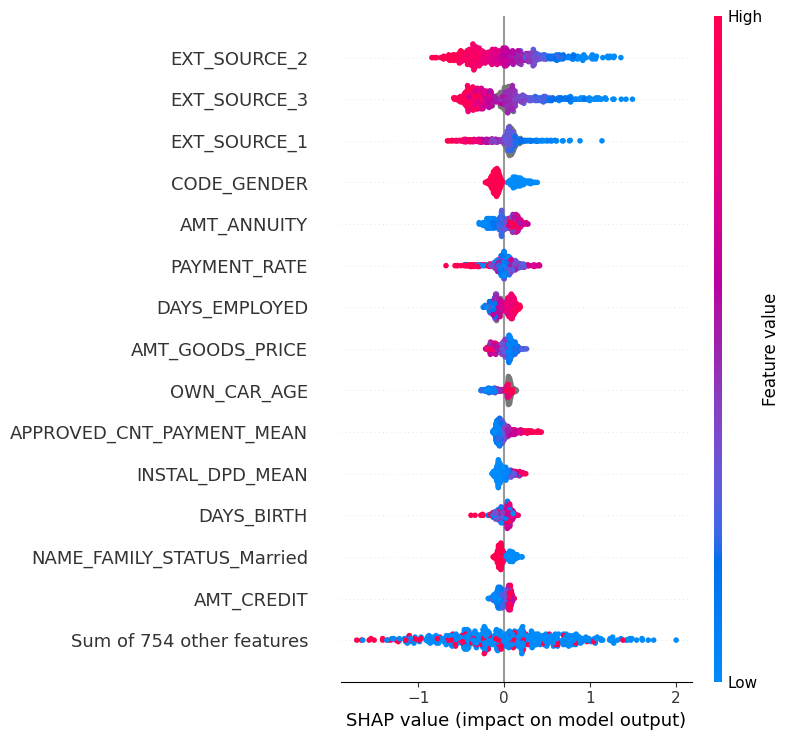

In [10]:
import shap

# Sample X_test pour limiter le temps de calcul (500 observations suffisent pour le global)
shap_sample = X_test.sample(500, random_state=42)

explainer = shap.TreeExplainer(best_model)
shap_values = explainer(shap_sample)

# Beeswarm — importance globale + direction d'effet
shap.plots.beeswarm(shap_values, max_display=15, show=False)
fig_shap_beeswarm = plt.gcf()
plt.tight_layout()
plt.show()

### Exemples individuels

Deux clients représentatifs : un prédit à haut risque (proba élevée), un prédit à faible risque.

Client haut risque  — proba=0.917, TARGET réel=1
Client faible risque — proba=0.018, TARGET réel=0

--- Waterfall : client haut risque ---


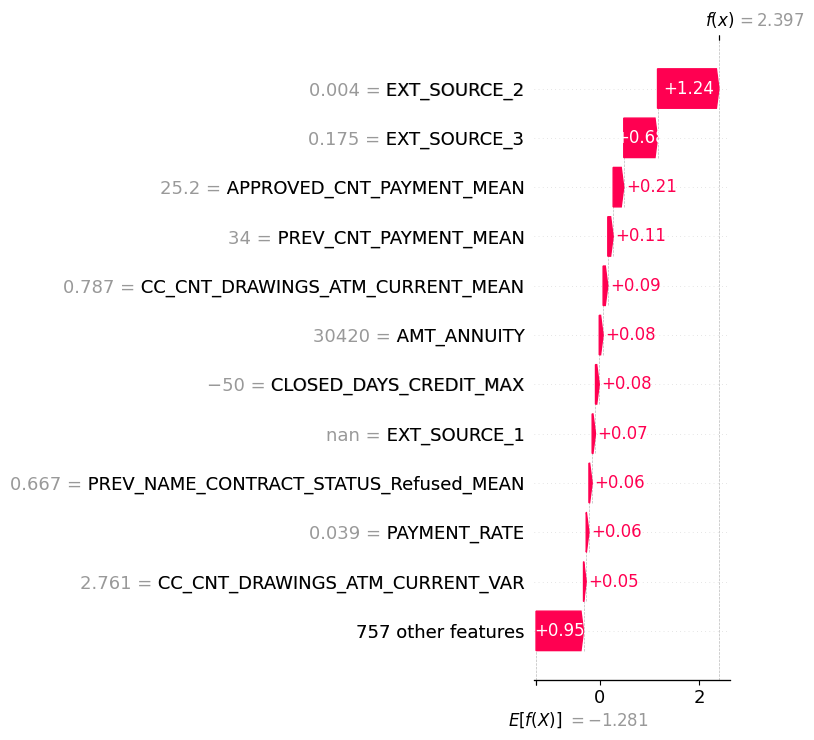


--- Waterfall : client faible risque ---


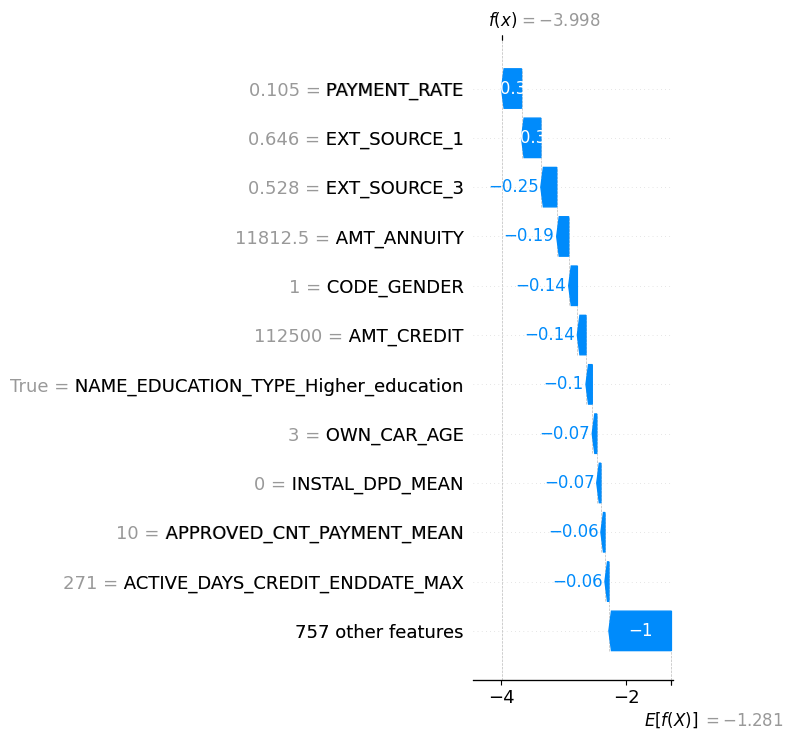

In [14]:
# Probas sur le sample SHAP pour choisir les exemples
proba_sample = best_model.predict_proba(shap_sample)[:, 1]

# Client à haut risque : proba la plus élevée
idx_high = proba_sample.argmax()
# Client à faible risque : proba la plus faible
idx_low = proba_sample.argmin()

print(f"Client haut risque  — proba={proba_sample[idx_high]:.3f}, TARGET réel={y_test.loc[shap_sample.index[idx_high]]}")
print(f"Client faible risque — proba={proba_sample[idx_low]:.3f}, TARGET réel={y_test.loc[shap_sample.index[idx_low]]}")

# Waterfall client haut risque
print("\n--- Waterfall : client haut risque ---")
shap.plots.waterfall(shap_values[idx_high], max_display=12, show=False)
fig_shap_wf_high = plt.gcf()
plt.tight_layout()
plt.show()

# Waterfall client faible risque
print("\n--- Waterfall : client faible risque ---")
shap.plots.waterfall(shap_values[idx_low], max_display=12, show=False)
fig_shap_wf_low = plt.gcf()
plt.tight_layout()
plt.show()


## <a id='toc7_5_'></a>[Artefacts — logging dans MLflow](#toc0_)

In [ ]:
N_TRIALS = 100
client = MlflowClient()
exp = client.get_experiment_by_name(EXPERIMENT_NAME)
runs = client.search_runs(
    exp.experiment_id, filter_string="tags.mlflow.runName = 'lgbm_optuna_best_full'"
)
best_run_id = runs[0].info.run_id

with mlflow.start_run(run_id=best_run_id):
    mlflow.log_param("n_trials", N_TRIALS)
    mlflow.log_metrics(test_metrics)
    with tempfile.TemporaryDirectory() as tmpdir:
        # Artefacts Plotly
        for fig, name in [
            (
                optuna.visualization.plot_optimization_history(study),
                "optimization_history",
            ),
            (optuna.visualization.plot_param_importances(study), "param_importances"),
            (fig_thresh, "cost_vs_threshold"),
            (fig_imp, "feature_importances_top10"),
            (fig_cm, "confusion_matrix_test"),
        ]:
            path = os.path.join(tmpdir, f"{name}.html")
            fig.write_html(path)
            mlflow.log_artifact(path)


mlflow.register_model(
    f"runs:/{best_run_id}/lgbm_optuna_best_full", "lgbm_credit_scoring"
)
print("Modèle enregistré dans le registry sous 'lgbm_credit_scoring'.")

🏃 View run lgbm_optuna_best_full at: http://127.0.0.1:5000/#/experiments/3/runs/b298ae7fcceb49118aa342716d79bb95
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/3


NameError: name 'test_metrics' is not defined

In [19]:
with mlflow.start_run(run_id=best_run_id):
    with tempfile.TemporaryDirectory() as tmpdir:
        for fig_mpl, name in [
            (fig_shap_beeswarm, "shap_beeswarm_global"),
            (fig_shap_wf_high, "shap_waterfall_high_risk"),
            (fig_shap_wf_low, "shap_waterfall_low_risk"),
        ]:
            path = os.path.join(tmpdir, f"{name}.png")
            fig_mpl.savefig(path, bbox_inches="tight", dpi=150)
            mlflow.log_artifact(path)
print("Artefacts SHAP loggués.")


🏃 View run lgbm_optuna_best_full at: http://127.0.0.1:5000/#/experiments/3/runs/b298ae7fcceb49118aa342716d79bb95
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/3
Artefacts SHAP loggués.
